# **12. Introducción a Deep Learning**

## **12.1. Una simple neurona (Introducción)**

### **12.1.1. ¿Que es Deep Learning?**
Es un enfoque de Machine Learning el cual utiliza varias capas de computación profunda. Estas capas son las que permiten al Deep Learning a resolver problemas más complejos.

Gracias a su poder y escalibilidad las **redes neuronales** se han convertido en el modelo de definición de Deep Learning. Las redes neuronales estan compuestas de neuronas, de las cuales cada neurona individualmente realiza una sola operación de computación, el poder de la neurona proviene de la complejidad de las conexiones que se pueden hacer entre ellas.

### **12.1.2. La unidad lineal**
La forma más basica que hay en Deep Learning es la neurona que se representa de la siguiente forma:

![imagen](./images/deepLearningNeuronaTabla.png)<br>
<ins>*La Unidad Lineal: y = wx + b*</ins>

La entrada es *x*. Su conexión con la neurona tiene un peso (weight) *w*. Cada vez que un valor fluye a través de una conexión, se multiplica dicho valor por el peso de la conexión. Para la entrada x, lo que llega a la neurona es w * x. Una red neuronal ''aprende'' modificando sus pesos.

La *b* es un tipo especial de peso que denominamos ''sesgo'' (bias). El sesgo no tiene asociados datos de entrada; en su lugar, colocamos un 1 en el diagrama para que el valor que llega a la neurona sea simplemente b (ya que 1 * b = b). El sesgo permite a la neurona modificar la salida independientemente de sus entradas.

La *y* es el valor que la neurona emite finalmente. Para obtener la salida, la neurona suma todos los valores que recibe a través de sus conexiones. La activación de esta neurona es `y = w * x + b`, o, en forma de fórmula, `y = wx + b.` La formula `y = wx + b` es la ecuación de una recta.

#### **12.1.2.1. Ejemplo - de la Unidad lineal**
Ya que las neuronas individuales suelen funcionar como parte de una red más larga, es util empezar con una neurona simple como modelo como ejemplo. Los modelos de neuronas simples son modelos lineales.

Por ejemplo usando una base de datos que contiene información sobre cereales, se puede entrenar un modelo con el dato de entrada (input) ''sugar'' (azucar), y ''calorias'' (calories) como un resultado (output), tambien suponemos que el sesgo (bias) es de `b=90` y el peso (weight) es de `w=2.5`. Asi que se puede estimar que el contenido caoliro de un cereal con 5 gramos de azucar es: 

![imagen](./images/unidadLinealTablaEjemplo.png)<br>
<ins>*Operando con la unidad lineal*</ins>

Y usando la formula de las calorias, se puede observar que tengo `calorias = 2.5 x 5 + 90 = 102.5`, igual que el resultado dado por la neurona.

### **12.1.3. Multiples entradas**
Utilizando la base de datos del apartado anterior podemos ver que el conjunto de datos ''80 Cereals'' tiene muchas más características además de los ''azúcares''. ¿Y si quisiéramos ampliar nuestro modelo para incluir aspectos como el contenido en fibra o en proteínas? Es bastante sencillo. Solo tenemos que añadir más conexiones de entrada a la neurona, una por cada característica adicional. Para calcular la salida, multiplicaríamos cada entrada por el peso de su conexión y, a continuación, sumaríamos todos los resultados.

![](./images/neuronaConMultiplesEntradasTabla.png)<br>
<ins>*Una unidad lineal con tres datos de entrada.*</ins>

La formula de la neurona seria $y = w_0x_0 + w_1x_1 + w_2x_2 + b$. Una unidad lineal con dos datos de entrada los cuales llenan un plano, y una unidad con muchas entradas de las que se pueden introducir en un hiper plano.

### **12.1.4. Creacion de una neurona con multiples datos de entrada con keras**

In [2]:
from tensorflow import keras
from tensorflow.keras import layers

# Create a network with 1 linear unit
model = keras.Sequential([
    layers.Dense(units=1, input_shape=[3])
])

## **12.2. Redes neuronales profundas (Deep Neural Networks**)
En esta parte se va a ver como construir una red neuronal capaz de aprender relaciones complejas por las cuales son famosas dichas redes neuronales.

La idea principal es la modularidad que ofrecen estas redes complejas de neuronas desde las unidades funcionales simples.

### **12.2.1. Capas**
Las redes neuronales normalmente se organizan en capas, las cuales junta unidades lineales que tiene en comun un conjunto de datos de entrada, y entonces de aquí se consigue una capa densa.

![](./images/capasRedesNeuronalesProfundasTablas.png) <br>
<ins>*Una capa densa con dos unidades lineales las cuales reciben dos datos de entrada y un sesgo.*</ins>

Se puede pensar que cada capa de la red neuronal esta realizando algun tipo de cambio/transformación simple. En un conjunto de capas profundas, una red neuronal puede tranformar sus datos de entrada en operaciones mucho más complejas. En una red neuronal bien entrenada, cada capa es una transformación que te acerca al resultado final.

>**Muchos tipos de capas**<br>Una ''capa'' en Keras es un concepto muy general. Una capa puede ser, en esencia, cualquier tipo de transformación de datos. Muchas capas, como las convolucionales y las recurrentes, transforman los datos mediante el uso de neuronas y se diferencian principalmente en el patrón de conexiones que forman.

### **12.2.2. La función de activación**
Acontece que dos capas densas sin nada de por medio, no son mejores que una capa densa sola. Las capas densas por si solas nunca van a poder sacarnos del mundo de las lineas y los planos, por lo tanto lo que necesitamos es algo *no lineal*, para eso se utilizan las funciones de activación.

![](./images/funcionActivacionTabla.png)<br>
<ins>*Sin las funciones de activación, las redes neuronales solo pueden aprender relaciones lineales, de forma que para ajustarse a curvas, se necesitan usar funciones de activación.*</ins>

Una función de activación es simplemente una función que se le aplica a la salida de la capa (sus activaciones). La más común es la función rectificadora $max(0,x)$.

![](./images/funcionRectificadoraTabla.png)

La función rectificadora tiene un grafico el cual la linea de la parte negativa es ''rectificada'' a cero. Usando esta función con el resultado de las neuronas se pueden *doblar* los datos, asi consiguiendo funciones diferentes de las funciones lineales.

Cuando se le aplica el rectificador a la unidad lineal, se consigue una **unidad rectificadora lineal** (rectified linear unit) o **ReLU**. por esta razón lo más comun es llamar a la función rectificadora como función ReLU. Aplicando la activación ReLU a la unidad lineal significa que el resultado (output) se convierte en $max(0, w * x + b)$, lo cual en un diagrama se ve de la siguiente forma:

![](./images/neuronaConFuncionReLUTabla.png)<br>
<ins>*Una unidad lineal rectificadora.*</ins>

### **12.2.3. Apilando capas densas**
Una vez que se consigue escapar de la linealidad, se puede hacer uso de lo siguiente:

![](./images/apilacionDeCapasOcultasTabla.png)<br>
<ins>*Una apilación de capas densas las cuales constituyen una red ''totalmente conectada''.*</ins>

Las capas que se encuentran antes de la capa de salida se llaman capas ocultas, ya que nunca se ve el resultado de estas directamente.

Como se puede observar en la imagen anterior la capa final es una unidad lineal, lo cual significa que no contiene una función de activación. Esto hace que sea adecuada para una tarea de regresión, en la cual se esta intentando predecir algun valor numerico albitrario. Pero en otras tareas como claficación de elementos, se puede llegar a requerir una funciones de activación en la salida.

## **12.3. Descenso por gradiente estocástico**
- <ins>*estocástico*</ins>-> perteneciente al azar

Los anteriores dos puntos se ve como se puede crear una red totalmente conectada gracias a las apilaciones de las capas densas. Pero como se puede suponer la red cuando se crea asigna los pesos de forma aleatoria esto significando que la red neuronal no sabe nada por ahora, por lo tanto lo que se va a ver en este punto es como hacer el entrenamiento a dicha red neuronal.

Como todo lo relacionado con empezar a entrenar dentro de Machine Learning, primero se necesita una set de datos de entrenamiento. Cada ejemplo de los datos de entrenamiento consiste en algunas caracteristicas (los datos de entrada) los cuales se juntan con el objetivo esperado (el resultado). Entrenar una red neuronal significa ajustar los pesos de tal formaq eu se puedan transformar las caracteristicas en el objetivo. Si se consigue entrenar de forma exitosa una red neuronal para hacer eso los pesos deben de representar de alguna forma las relaciones entre las caracteristicas y el objetivo segun como se hayan representado en los datos de entrenamiento.

Y hay que tener dos cosas mas en cuenta a la hora de entrenar una red neuronal, primero se necesita una función de perdidas la cual mida como de buenas son las predicciones que hace la red neuronal y despues se necesita un optimizador el cual le pueda indicar a la red neuronal como cambiar sus pesos.

#### **12.3.1. La función de perdida**
Esta función se encarga de decirle a la red neuronal que problema tiene que resolver, de forma que la función de perdida lo que mide es la diferencia entre el valor verdadero de la función objetivo y el valor que el modelo predice.

Una función de perdida común para los problemas de regresión es el **error del valor absoluto medio** (mean absolute error) o **MAE**. Para cada predicción `y_pred`, MAE mide la dispariedad del valor verdadero `y_true` mediante una diferencia absoluta `abs(y_true - y_pred)`.

La perdida total de MAE en el conjunto de datos es la media de todas las diferencias absolutas.

![](./images/MAETable.png)<br>
<src>*El error absoluto medio es la longitud media entre la curva ajustada y los puntos de los datos.*</src>

A parte de la MAE, hay otras funciones de perdida las cuales pueden aparecer en problemas de regresion las cuales son el **error cuadratico medio (MSE)** o la **perdida de Huber**.

Durante el entrenamiento, el modelo usara la función de perdida como guia para encontrar los valores correcto a los pesos (más bajo es mejor). Es decir que la función de perdida le dice a la red neuronal su objetivo.

#### **12.3.2. El optimizador - el descenso del gradiente estocástico**
El optimizador se encarga de decirle a la red neuronal como resolver el problema, ya que este es un algoritmo el cual ajusta el valor de los pesos para minimizar la pérdida.

Virtualmente todos los algoritmos usados en Deep Learning pertenecen a la famlia llamada **descenso del gradiente estocástico**. Son algoritmos iterativoslos cuales entrenan las redes neuronales en pasos, por ejemplo un paso de entrenamiento seria algo asi:
1.  Selecciona una muestra de datos de entrenamiento y procesa esa muestra a través de la red para realizar predicciones.
2. Mide la pérdida entre las predicciones y los valores reales.
3. Por último, ajusta los pesos en la dirección que reduzca la pérdida.

Entonces se realiza de forma iterativa una y otra vez hasta que la pérdida es tan pequeña como se necesite o hasta que no decremente más la pérdida.

![](./images/optimizadorDelGradienteGIF.gif)<br>
<ins>*Entrenamineto de una red neuronal con un descenso del gradiente estocástico.*</ins>

Cada ejemplo de una iteración de datos de entrenamientoses llamado **mini lote (minibatch)** (a veces tambien se le llama solo ''lote'' (batch)), mientras que una ronda completa de datos de entrenamiento es llamado **época (epoch)**. El número de épocas durante las que se realiza el entrenamiento corresponde al número de veces que la red verá cada ejemplo de entrenamiento.

La animación muestra el modelo lineal de la Lección 1 entrenándose con SGD. Los puntos de color rojo pálido representan el conjunto de entrenamiento completo, mientras que los puntos rojos sólidos son los minilotes. Cada vez que el SGD procesa un nuevo minilote, ajusta los pesos (w, la pendiente, y b, la ordenada en el origen) hacia sus valores correctos para ese lote. Lote tras lote, la línea acaba convergiendo hacia su mejor ajuste. Se puede observar que la pérdida se reduce a medida que los pesos se acercan a sus valores reales.

### **12.3.3. Ratio de aprendizaje y tamaño de lotes**
Hay que notar que la linea solo hace un pequeño ajuste en la dirección de cada lote (en vez de moverse directamente a la solución). El tamaño de estos ajustes viene determinado por el **ratio de aprendizaje**. Un ratio de aprendizaje menor significa que la red neuronal necesita ver más mini lotes antes de que sus pesos converjan hacia sus mejores valores.

El ratio de aprendizaje y el tamaño de los minlotes son dos parametros los cuales tiene el mayor impacto en como el proceso de entrenamiento SGD procede. Su interacción normalmente es sutil y la repuesta correcta para dichos parametros muchas veces no es obvia.

Afortunadamente, en la mayoría de los casos no será necesario realizar una búsqueda exhaustiva de hiperparámetros para obtener resultados satisfactorios. **Adam** es un algoritmo SGD que cuenta con una tasa de aprendizaje adaptativa, lo que lo hace adecuado para la mayoría de los problemas sin necesidad de ajustar ningún parámetro (en cierto sentido, se ''autoajusta''). Adam es un excelente optimizador de uso general.

### **12.3.4. Añadiendo la perdida y el optimizador**
Despues de definir el modelo, se puede añadir la furncion de perdida y el optimizador con el método de compilacion del modelo:

```Python
model.compile(
    optimizer="adam",
    loss="mae",
)
```

Notesé en que se puede especificar la función de pérdida y el optimizador con solo una cadena de caracteres. También se puede acceder a ellos directamente a través de la API de Keras *por ejemplo, si se quisiera ajustar los parámetros**, pero en nuestro caso los valores por defecto funcionarán perfectamente.

>**¿Qué hay en un nombre?** <br> El gradiente es un vector que nos indica en qué dirección deben moverse los pesos. Más concretamente, nos indica cómo modificar los pesos para que la pérdida cambie lo más rápido posible. Llamamos a nuestro proceso «descenso por gradiente» porque utiliza el gradiente para descender por la curva de pérdida hacia un mínimo. «Estocástico» significa «determinado por el azar». Nuestro entrenamiento es estocástico porque los minilotes son muestras aleatorias del conjunto de datos. ¡Y por eso se llama SGD!

### **12.3.5. Ejemplo - Calidad del vino tinto**
Ahora ya sabemos todo lo necesario para empezar a entrenar modelos de aprendizaje profundo. ¡Veamos cómo funciona en la práctica! Utilizaremos el conjunto de datos «Red Wine Quality».

Este conjunto de datos está compuesto por mediciones fisicoquímicas de unos 1.600 vinos tintos portugueses. También incluye una valoración de la calidad de cada vino obtenida a partir de catas a ciegas. ¿Hasta qué punto podemos predecir la calidad percibida de un vino a partir de estas mediciones?

Hemos incluido toda la preparación de los datos en la siguiente celda oculta. No es imprescindible para lo que viene a continuación, así que no dudes en saltártela. Sin embargo, algo que quizá te llame la atención por ahora es que hemos reescalado cada característica para que se sitúe en el intervalo [0,1]. Como veremos con más detalle en la lección 5, las redes neuronales suelen ofrecer mejores resultados cuando sus entradas se encuentran en una escala común.

In [4]:
import pandas as pd
from IPython.display import display

red_wine = pd.read_csv('./red-wine.csv')

# Create training and validation splits
df_train = red_wine.sample(frac=0.7, random_state=0)
df_valid = red_wine.drop(df_train.index)
display(df_train.head(4))

# Scale to [0, 1]
max_ = df_train.max(axis=0)
min_ = df_train.min(axis=0)
df_train = (df_train - min_) / (max_ - min_)
df_valid = (df_valid - min_) / (max_ - min_)

# Split features and target
X_train = df_train.drop('quality', axis=1)
X_valid = df_valid.drop('quality', axis=1)
y_train = df_train['quality']
y_valid = df_valid['quality']



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1109,10.8,0.470,0.43,2.10,0.171,27.0,66.0,0.99820,3.17,0.76,10.8,6
1032,8.1,0.820,0.00,4.10,0.095,5.0,14.0,0.99854,3.36,0.53,9.6,5
1002,9.1,0.290,0.33,2.05,0.063,13.0,27.0,0.99516,3.26,0.84,11.7,7
487,10.2,0.645,0.36,1.80,0.053,5.0,14.0,0.99820,3.17,0.42,10.0,6


¿Cuántas entradas debería tener esta red? Podemos averiguarlo fijándonos en el número de columnas de la matriz de datos. Asegúrate de no incluir aquí la variable de destino («calidad»); solo las características de entrada.

In [7]:
print(X_train.shape)

(1119, 11)


Once columnas significan once entradas.

Hemos elegido una red de tres capas con más de 1.500 neuronas. Esta red debería ser capaz de aprender relaciones bastante complejas en los datos.

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=[11]),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(1),
])

La elección de la arquitectura de tu modelo debe formar parte de un proceso. Empieza por algo sencillo y utilice la pérdida de validación como guía. Aprenderás más sobre el desarrollo de modelos en los ejercicios.

Una vez definido el modelo, incorporamos el optimizador y la función de pérdida.

In [11]:
model.compile(
    optimizer='adam',
    loss='mae',
)

¡Ya estamos listos para empezar el entrenamiento! Le hemos indicado a Keras que envíe al optimizador 256 filas de los datos de entrenamiento cada vez (el «batch_size») y que repita este proceso 10 veces a lo largo de todo el conjunto de datos (las «epocas»).


In [13]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=10,
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1011 - val_loss: 0.1030
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0989 - val_loss: 0.0985
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0980 - val_loss: 0.0984
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0967 - val_loss: 0.0994
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0956 - val_loss: 0.0991
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0940 - val_loss: 0.0979
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0953 - val_loss: 0.0950
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0946 - val_loss: 0.0983
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0967 - val_loss: 0.0978
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0961 - val_loss: 0.1044


Como puedes ver, Keras te mantendrá informado sobre la pérdida a medida que se entrena el modelo.

Sin embargo, a menudo la mejor forma de visualizar la pérdida es representarla gráficamente. De hecho, el método `fit` guarda un registro de la pérdida generada durante el entrenamiento en un objeto `History`. Convertiremos los datos a un dataframe de Pandas, lo que facilita la representación gráfica.

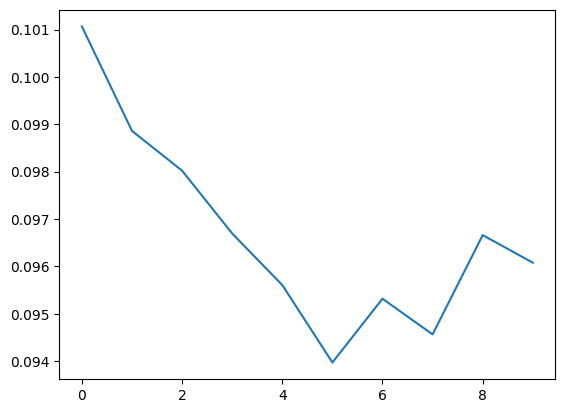

In [15]:
import pandas as pd

# convert the training history to a dataframe
history_df = pd.DataFrame(history.history)
# use Pandas native plot method
history_df['loss'].plot();

Fíjate en cómo la pérdida se estabiliza a medida que pasan las épocas. Cuando la curva de pérdida se vuelve horizontal como se ve aquí, significa que el modelo ha aprendido todo lo que podía y que no habría motivo para continuar con épocas adicionales.